This notbook uses silhouette scores to identify elections for which 3-clustering is better than 2-clustering, and analyzes a few such elections.

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import glob
from Clustering_Functions import *

In [15]:
filename_list = glob.glob("scot-elex/**/*.csv")
df = pd.DataFrame(columns=['filename', 'num_cands', 'sil'])

for filename in filename_list:
    num_cands, election, cand_names, location = csv_parse(filename)
    X = np.array([Borda_vector(ballot, num_cands=num_cands) for ballot in election.keys()])
    sample_weight = np.array([election[ballot] for ballot in election.keys()])

    sil_scores = []
    for k in range(2,6):
        kmeans = KMeans(n_clusters=k, n_init = 5).fit(X,sample_weight=sample_weight)
        labels = kmeans.labels_
        sil_scores.append(round(silhouette_score(X,labels),3))
    row_num = df.shape[0]
    if row_num%50 == 0:
        print(row_num)
    df.loc[row_num] = [filename, num_cands, tuple(sil_scores)]


0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050


In [20]:
best_k = []
gap = []
for count in range(len(df)):
    sil = df['sil'][count]
    best_k.append(np.argmax(sil)+2)
    gap.append(sil[1]-sil[0])
df['best_k']=best_k
df['gap']=gap

<Axes: xlabel='best_k', ylabel='Count'>

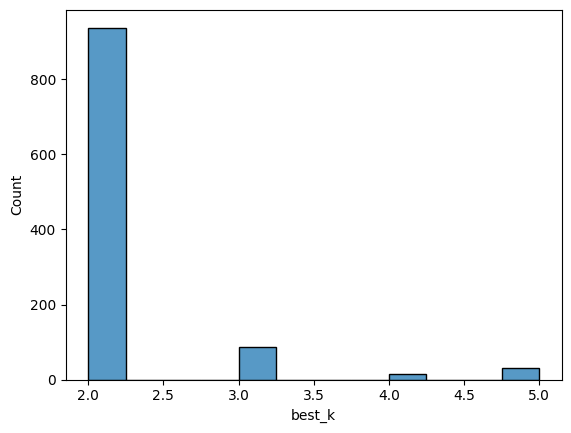

In [23]:
sns.histplot(data=df, x='best_k')

In [48]:
np.max(df['gap']), np.argmax(df['gap'])

(0.17700000000000005, 110)

In [30]:
filename = df['filename'][110]

In [33]:
num_cands, election, cand_list, ward =  csv_parse(filename)
party_names = party_abrevs(cand_list)

In [38]:
num_cands, cand_list

(3,
 [('Kenny', 'Barker', 'Conservative and Unionist Party (Con)'),
  ('Mustapha', 'Hocine', 'Independent (Ind)'),
  ('Uisdean', 'Robertson', 'Independent (Ind)')])

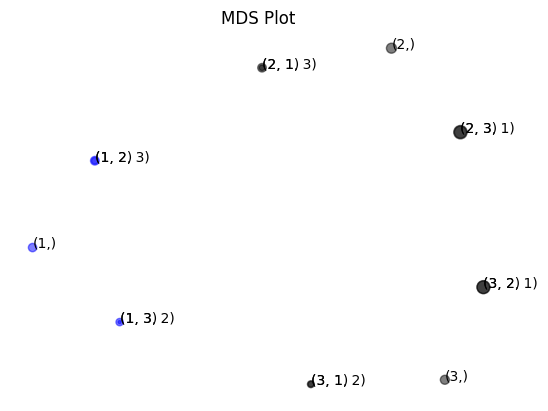

In [40]:
Ballot_MDS_plot(election, party_names=party_names, threshold=1, label_threshold=1, )

In [37]:
Summarize_election(election, size= 14)

This election has: 3 candidates, 661 ballots, 15 distinct ballots, 2.24 avg ballot length.
Top ballots:
 	 94 votes for (2, 3). 
 	 89 votes for (3, 2). 
 	 81 votes for (3, 2, 1). 
 	 76 votes for (2, 3, 1). 
 	 52 votes for (2,). 
 	 42 votes for (3,). 
 	 39 votes for (1, 2, 3). 
 	 38 votes for (2, 1, 3). 
 	 36 votes for (1,). 
 	 28 votes for (1, 3, 2). 
 	 25 votes for (3, 1, 2). 
 	 23 votes for (1, 2). 
 	 17 votes for (3, 1). 
 	 16 votes for (2, 1). 
 	 5 votes for (1, 3). 


In [43]:
df3 = df[df['best_k']==3]
len(df3)

87

In [54]:
df.head(30)

,filename,num_cands,sil,best_k,gap
111,scot-elex\3_cands\eilean_siar_2022_ward4.csv,3,"(0.364, 0.541, 0.535, 0.577)",5,0.177
110,scot-elex\3_cands\eilean_siar_2022_ward3.csv,3,"(0.364, 0.541, 0.535, 0.577)",5,0.177
143,scot-elex\4_cands\south_ayrshire_2012_ward6.csv,4,"(0.227, 0.287, 0.297, 0.298)",5,0.060
142,scot-elex\4_cands\shetland_2017_ward6.csv,4,"(0.215, 0.267, 0.286, 0.271)",4,0.052
147,scot-elex\4_cands\stirling_2012_ward5.csv,4,"(0.235, 0.287, 0.289, 0.299)",5,0.052
119,scot-elex\4_cands\clackmannanshire_2012_ward5.csv,4,"(0.226, 0.271, 0.241, 0.245)",3,0.045
124,scot-elex\4_cands\east_dunbartonshire_2012_war...,4,"(0.244, 0.287, 0.286, 0.273)",3,0.043
112,scot-elex\4_cands\aberdeenshire_2017_ward1.csv,4,"(0.244, 0.287, 0.27, 0.264)",3,0.043
132,scot-elex\4_cands\moray_2012_ward7.csv,4,"(0.217, 0.259, 0.237, 0.209)",3,0.042
138,scot-elex\4_cands\orkney_2012_ward6.csv,4,"(0.248, 0.29, 0.291, 0.316)",5,0.042


In [55]:
filename = 'scot-elex\9_cands\edinburgh_2012_ward4.csv'
num_cands, election, cand_list, ward =  csv_parse(filename)
party_names = party_abrevs(cand_list)

In [56]:
Summarize_election(election)

This election has: 9 candidates, 8097 ballots, 1669 distinct ballots, 2.99 avg ballot length.
Top ballots:
 	 810 votes for (2, 8). 
 	 691 votes for (5,). 
 	 424 votes for (1, 3). 
 	 269 votes for (3, 1). 
 	 189 votes for (2,). 
 	 183 votes for (5, 9). 
 	 170 votes for (1, 3, 6). 
 	 164 votes for (2, 8, 6). 
 	 143 votes for (8, 2). 
 	 86 votes for (3, 1, 6). 
 	 83 votes for (5, 6). 


In [61]:
party_names

['SNP', 'Lab', 'SNP', 'TUSC', 'Con', 'Gr', 'Lib', 'Lab', 'LD']

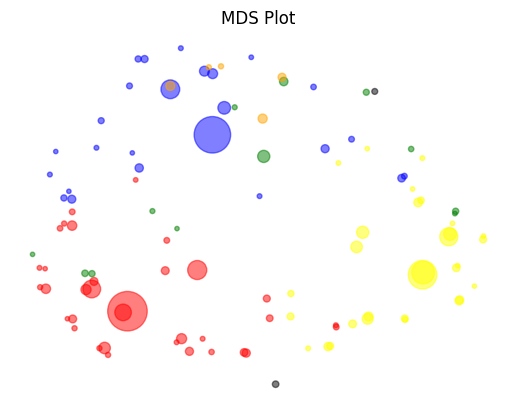

In [63]:
Ballot_MDS_plot(election, party_names=party_names, filename='skittles.jpg')

In [58]:
C = kmeans(election, k=3)

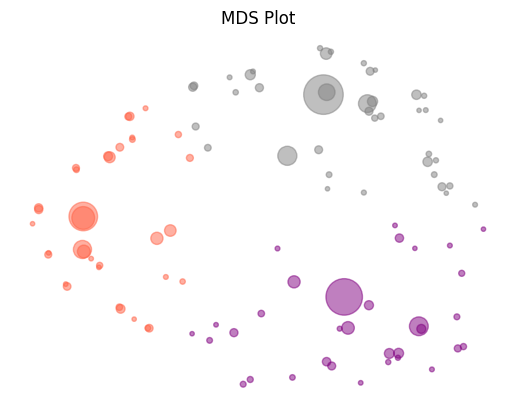

In [59]:
Ballot_MDS_plot(election, C)

In [83]:
filename = 'scot-elex/7_cands/edinburgh_2017_ward2.csv'
num_cands, election, cand_list, ward = csv_parse(filename)
parties = party_abrevs(cand_list)

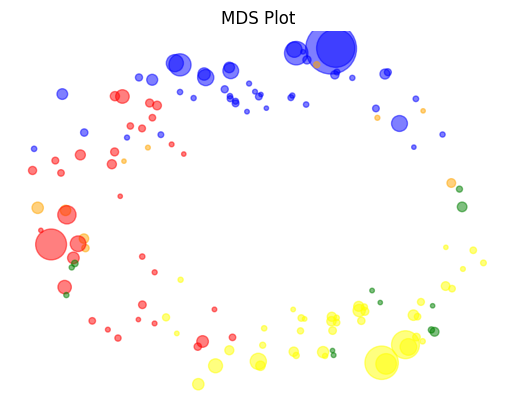

In [77]:
Ballot_MDS_plot(election, party_names = parties, filename='PH.jpg')

In [84]:
X = np.array([Borda_vector(ballot, num_cands=num_cands) for ballot in election.keys()])
sample_weight = np.array([election[ballot] for ballot in election.keys()])

sil_scores = []
for k in range(2,6):
    kmeans = KMeans(n_clusters=k, n_init = 5).fit(X,sample_weight=sample_weight)
    labels = kmeans.labels_
    sil_scores.append(round(silhouette_score(X,labels),3))


In [85]:
sil_scores

[0.239, 0.177, 0.161, 0.153]